# 07 - Comparación de modelos de detección de humo y fuego

Se consolidan los resultados obtenidos con las arquitecturas evaluadas sobre D-Fire:

- YOLOv8n
- YOLO11n
- YOLO26s
- Faster R-CNN
- RT-DETR-L

La comparación principal se realiza sobre el conjunto de test mediante Precision, Recall, F1, mAP@0.5 y mAP@0.5:0.95.

El notebook utiliza únicamente los artefactos versionados en el repositorio y no requiere volver a ejecutar los entrenamientos.

In [1]:
# ============================================================
# Setup
# ============================================================

from pathlib import Path
import sys

REPO_URL = "https://github.com/Gabriela-Sol/VpC2---Deteccion-de-humo-y-fuego.git"
REPO_BRANCH = "main"
REPO_NAME = "VpC2---Deteccion-de-humo-y-fuego"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:

    PROJECT_DIR = Path("/content") / REPO_NAME

    if not (PROJECT_DIR / ".git").exists():

        %cd /content

        !git clone \
            --branch {REPO_BRANCH} \
            --single-branch \
            {REPO_URL}

    %cd {PROJECT_DIR}

    !pip install -q -r {PROJECT_DIR / "requirements.txt"}

else:

    PROJECT_DIR = (
        Path.cwd().parent
        if Path.cwd().name == "notebooks"
        else Path.cwd()
    )

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("PROJECT_DIR:", PROJECT_DIR)

print("\nBranch actual:")
!git branch --show-current

PROJECT_DIR: /Users/marcoslund/git/ceia/VpC2---Deteccion-de-humo-y-fuego

Branch actual:
main


In [2]:
# ============================================================
# Carga de los resúmenes de cada experimento
# ============================================================

import pandas as pd

from src.reporting.summary import load_metrics_summaries

RESULTS_DIR = PROJECT_DIR / "reports" / "results"

df = load_metrics_summaries(RESULTS_DIR)

if df.empty:
    raise RuntimeError(
        f"No se encontró ningún metrics_summary.csv en {RESULTS_DIR}."
    )


# ------------------------------------------------------------
# Compatibilidad con summaries YOLO anteriores
# ------------------------------------------------------------

if "map50" in df.columns:

    if "mAP50" not in df.columns:
        df["mAP50"] = df["map50"]
    else:
        df["mAP50"] = df["mAP50"].fillna(df["map50"])


if "map50_95" in df.columns:

    if "mAP50_95" not in df.columns:
        df["mAP50_95"] = df["map50_95"]
    else:
        df["mAP50_95"] = df["mAP50_95"].fillna(df["map50_95"])


# ------------------------------------------------------------
# Experimentos incluidos
# ------------------------------------------------------------

ESPERADOS = {
    "yolov8n_baseline",
    "yolo11n_baseline",
    "yolo26s_baseline",
    "fasterrcnn_r50fpn",
    "rtdetr_l",
}

faltan = ESPERADOS - set(df["experiment"])

if faltan:
    raise RuntimeError(
        "Faltan resultados de los siguientes experimentos: "
        f"{sorted(faltan)}"
    )

df = df[
    df["experiment"].isin(ESPERADOS)
].copy()


# ------------------------------------------------------------
# Nombres para visualización
# ------------------------------------------------------------

MODEL_NAMES = {
    "yolov8n_baseline": "YOLOv8n",
    "yolo11n_baseline": "YOLO11n",
    "yolo26s_baseline": "YOLO26s",
    "fasterrcnn_r50fpn": "Faster R-CNN",
    "rtdetr_l": "RT-DETR-L",
}

df["Modelo"] = df["experiment"].map(MODEL_NAMES)


# Ordenar según la métrica principal
df = (
    df
    .sort_values("mAP50_95", ascending=False)
    .reset_index(drop=True)
)

print(f"Experimentos encontrados: {len(df)}")

print("\nModelos:")
for model in df["Modelo"]:
    print("-", model)

Experimentos encontrados: 5

Modelos:
- YOLO26s
- YOLOv8n
- YOLO11n
- RT-DETR-L
- Faster R-CNN


## Comparación global

La comparación principal se realiza utilizando métricas disponibles de forma homogénea para las cinco arquitecturas.

Se utiliza `mAP@0.5:0.95` como métrica principal de ranking, ya que evalúa simultáneamente la capacidad de detección y la precisión de localización sobre diferentes umbrales IoU.

In [3]:
# ============================================================
# Tabla comparativa principal
# ============================================================

tabla = df[
    [
        "Modelo",
        "precision",
        "recall",
        "f1",
        "mAP50",
        "mAP50_95",
    ]
].copy()

tabla.columns = [
    "Modelo",
    "Precisión",
    "Recall",
    "F1",
    "mAP@0.5",
    "mAP@0.5:0.95",
]

display(
    tabla.style
    .format({
        "Precisión": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "mAP@0.5": "{:.4f}",
        "mAP@0.5:0.95": "{:.4f}",
    })
    .background_gradient(
        subset=[
            "mAP@0.5",
            "mAP@0.5:0.95",
        ],
        cmap="Greens",
    )
)

,Modelo,Precisión,Recall,F1,mAP@0.5,mAP@0.5:0.95
0,YOLO26s,0.7857,0.7000,0.7404,0.7727,0.4428
1,YOLOv8n,0.7661,0.6884,0.7252,0.7588,0.4341
2,YOLO11n,0.7525,0.6896,0.7197,0.7526,0.4329
3,RT-DETR-L,0.7574,0.6900,0.7222,0.7509,0.4150
4,Faster R-CNN,0.7855,0.7259,0.7546,0.7489,0.4031


In [4]:
# ============================================================
# Desempeño por clase
# ============================================================

CLASS_COLUMNS = [
    "mAP50_smoke",
    "mAP50_fire",
    "mAP50_95_smoke",
    "mAP50_95_fire",
]

por_clase = df[
    ["Modelo"] + CLASS_COLUMNS
].copy()

# Algunos experimentos pueden no tener todavía
# métricas por clase registradas.
por_clase = por_clase.dropna(
    subset=CLASS_COLUMNS
)

por_clase.columns = [
    "Modelo",
    "mAP@0.5 smoke",
    "mAP@0.5 fire",
    "mAP@0.5:0.95 smoke",
    "mAP@0.5:0.95 fire",
]

display(
    por_clase.style.format({
        "mAP@0.5 smoke": "{:.4f}",
        "mAP@0.5 fire": "{:.4f}",
        "mAP@0.5:0.95 smoke": "{:.4f}",
        "mAP@0.5:0.95 fire": "{:.4f}",
    })
)

print(
    f"Métricas por clase disponibles para "
    f"{len(por_clase)} de {len(df)} modelos."
)

,Modelo,mAP@0.5 smoke,mAP@0.5 fire,mAP@0.5:0.95 smoke,mAP@0.5:0.95 fire
0,YOLO26s,0.8410,0.7045,0.5156,0.3699
1,YOLOv8n,0.8213,0.6963,0.5030,0.3651
2,YOLO11n,0.8200,0.6853,0.5056,0.3602
3,RT-DETR-L,0.7882,0.7137,0.4619,0.3682
4,Faster R-CNN,0.8132,0.6845,0.4549,0.3514


Métricas por clase disponibles para 5 de 5 modelos.


In [5]:
# ============================================================
# Eficiencia computacional
# ============================================================

EFFICIENCY_COLUMNS = [
    "params_M",
    "epochs",
    "train_time_min",
    "fps",
]

eficiencia = df[
    ["Modelo"] + EFFICIENCY_COLUMNS
].copy()

eficiencia = eficiencia.dropna(
    subset=EFFICIENCY_COLUMNS
)

eficiencia.columns = [
    "Modelo",
    "Parámetros (M)",
    "Épocas",
    "Entrenamiento (min)",
    "FPS",
]

display(
    eficiencia.style.format({
        "Parámetros (M)": "{:.2f}",
        "Épocas": "{:.0f}",
        "Entrenamiento (min)": "{:.2f}",
        "FPS": "{:.2f}",
    })
)

print(
    f"Información completa de eficiencia disponible para "
    f"{len(eficiencia)} de {len(df)} modelos."
)

,Modelo,Parámetros (M),Épocas,Entrenamiento (min),FPS
0,YOLO26s,9.95,50,313.56,179.65
1,YOLOv8n,3.01,50,243.23,457.17
2,YOLO11n,2.59,50,251.10,423.00
3,RT-DETR-L,31.99,30,562.91,29.49
4,Faster R-CNN,43.26,30,1111.56,6.96


Información completa de eficiencia disponible para 5 de 5 modelos.


map_por_modelo.png


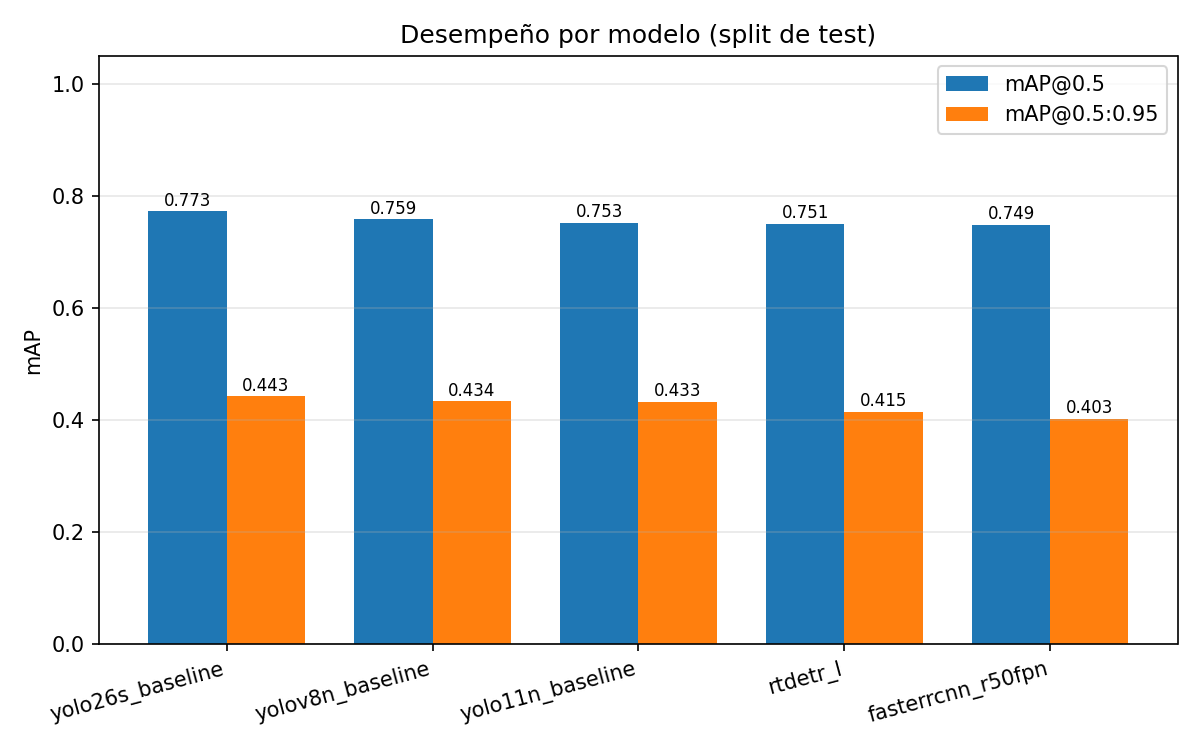

map_por_clase.png


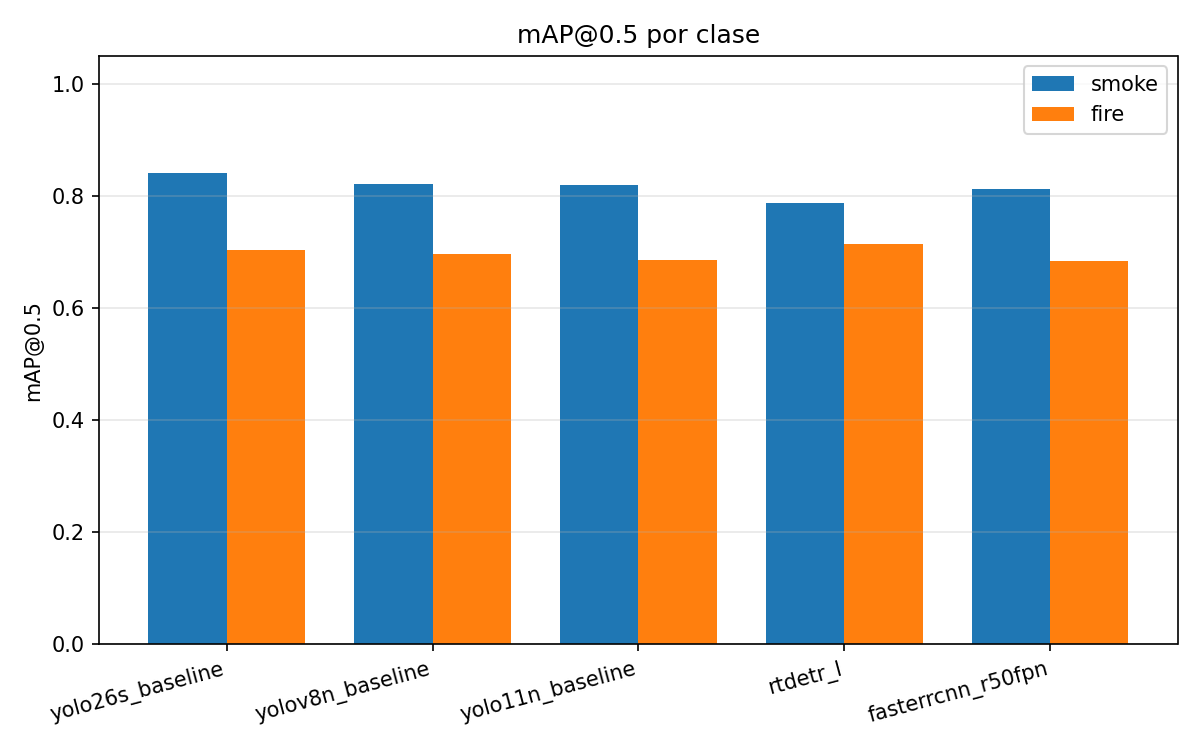

precision_vs_velocidad.png


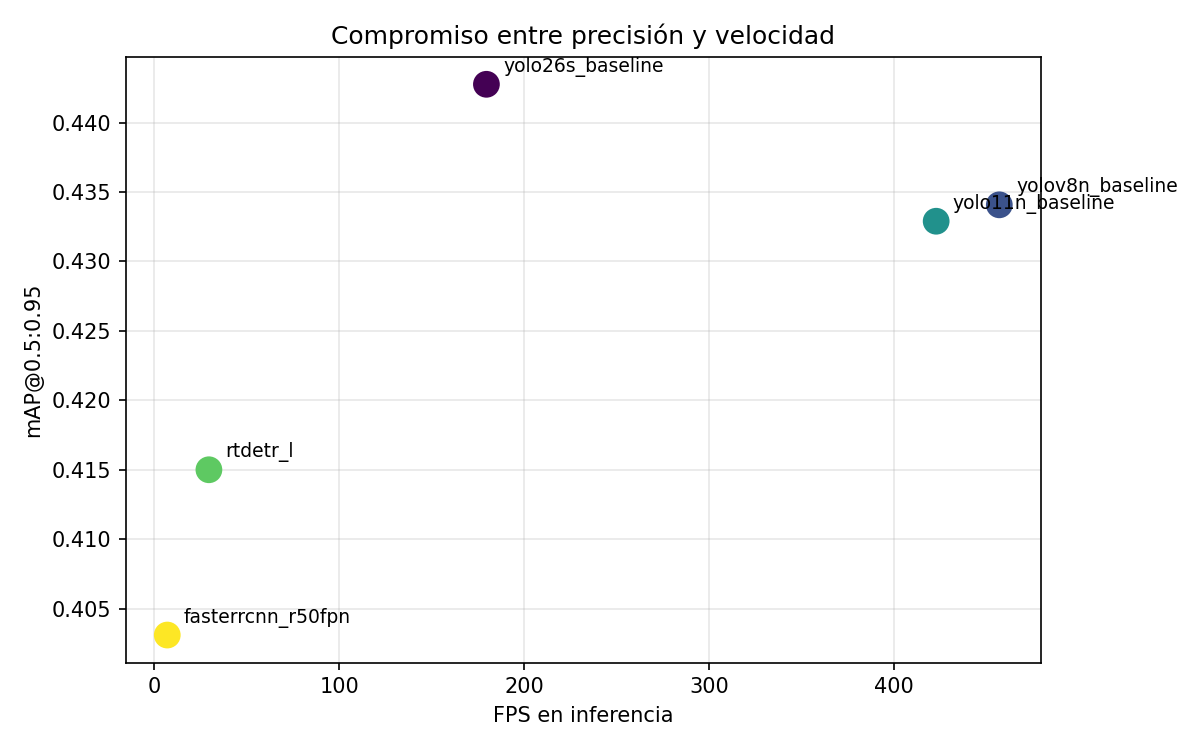

In [6]:
# ============================================================
# Figuras comparativas
# ============================================================

from IPython.display import Image, display

from src.reporting.plots import plot_model_comparison

FIGURES_DIR = (
    PROJECT_DIR
    / "reports"
    / "figures"
    / "comparacion"
)

rutas = plot_model_comparison(
    df,
    FIGURES_DIR,
)

for ruta in rutas:
    print(ruta.name)
    display(Image(filename=str(ruta)))

## Evolución a lo largo del entrenamiento

Además de las métricas finales, se analiza la evolución de las métricas sobre el conjunto de test a lo largo de las épocas utilizando los archivos `results.csv` disponibles para cada experimento.

Las funciones de pérdida no se comparan directamente entre arquitecturas debido a que utilizan formulaciones y escalas diferentes.

Épocas registradas por experimento:
experiment
fasterrcnn_r50fpn    30
rtdetr_l             30
yolo11n_baseline     50
yolo26s_baseline     50
yolov8n_baseline     50


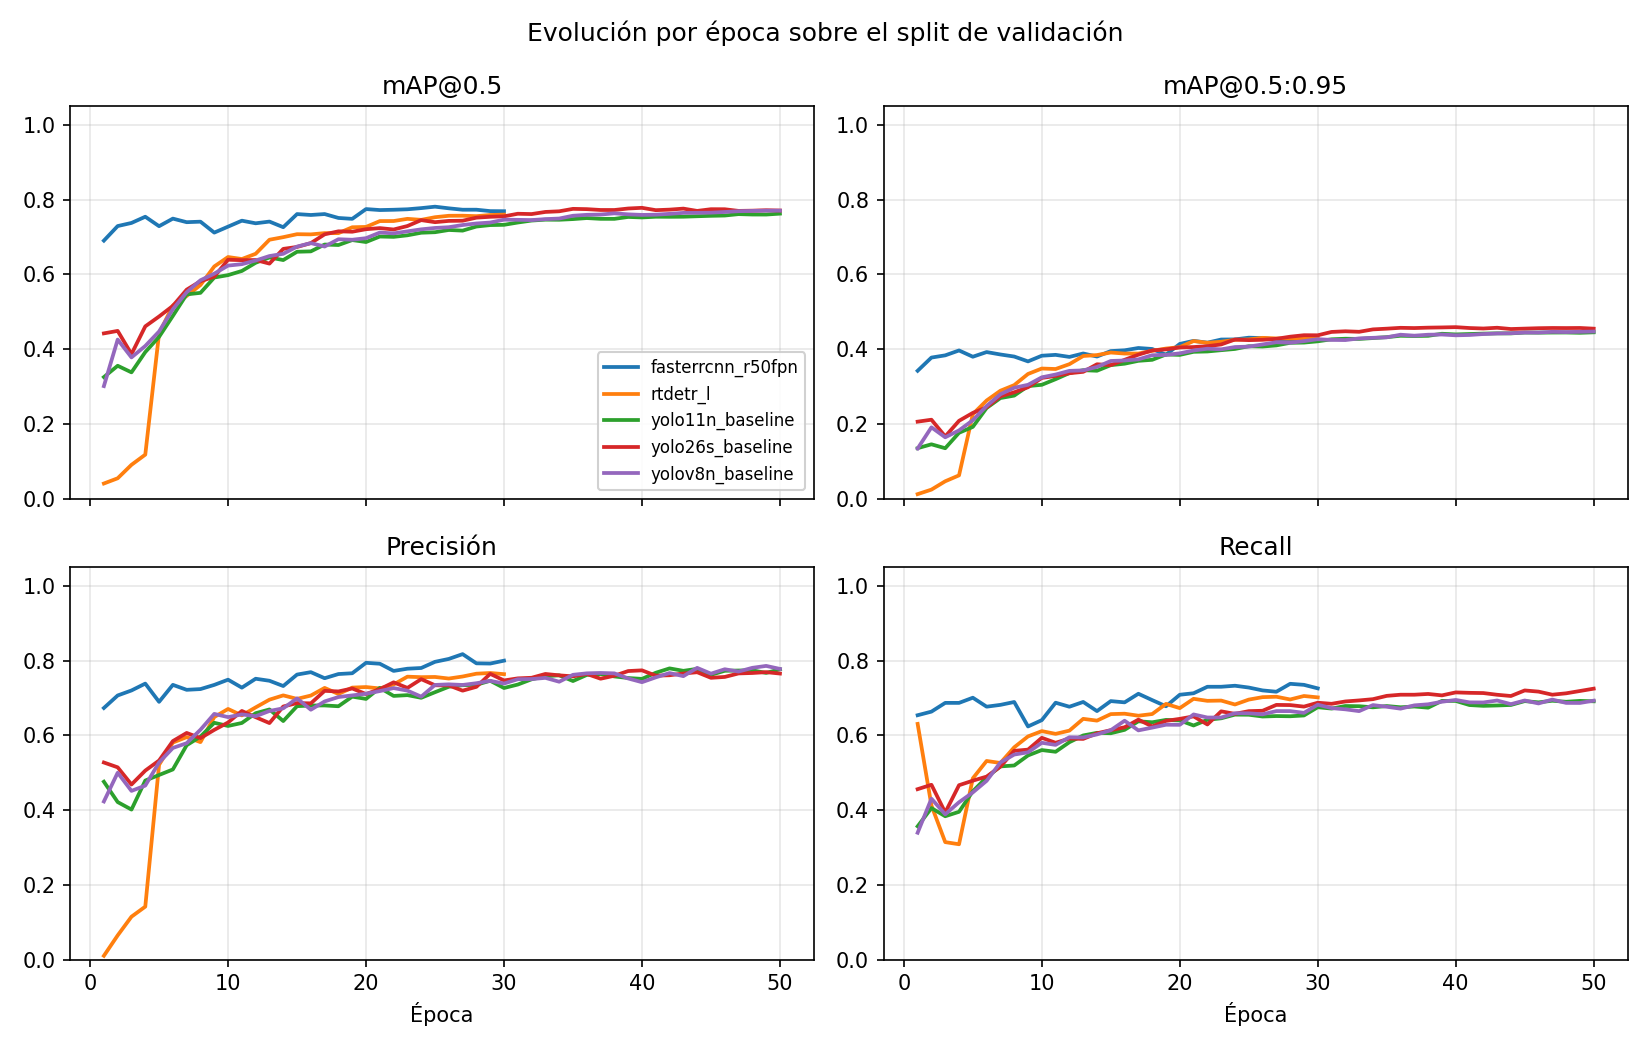

In [7]:
# ============================================================
# Evolución de las métricas por época
# ============================================================

from src.reporting.history import load_training_histories
from src.reporting.plots import plot_training_curves

historias = load_training_histories(
    RESULTS_DIR
)

if historias.empty:
    raise RuntimeError(
        f"No se encontró ningún results.csv con métricas "
        f"por época en {RESULTS_DIR}."
    )

print("Épocas registradas por experimento:")

print(
    historias
    .groupby("experiment")["epoch"]
    .max()
    .to_string()
)

ruta = plot_training_curves(
    historias,
    FIGURES_DIR,
)

display(
    Image(filename=str(ruta))
)

In [8]:
# ============================================================
# Exportación de la comparación
# ============================================================

COMPARISON_CSV = (
    PROJECT_DIR
    / "reports"
    / "results"
    / "comparacion_modelos.csv"
)

EXPORT_COLUMNS = [
    "experiment",
    "Modelo",
    "family",
    "model",
    "params_M",
    "epochs",
    "imgsz",
    "batch",
    "train_time_min",
    "mAP50",
    "mAP50_95",
    "precision",
    "recall",
    "f1",
    "mAP50_smoke",
    "mAP50_fire",
    "mAP50_95_smoke",
    "mAP50_95_fire",
    "fps",
    "device",
    "split",
    "best_epoch",
]

# Algunas columnas pueden todavía no existir
# en summaries antiguos.
EXPORT_COLUMNS = [
    column
    for column in EXPORT_COLUMNS
    if column in df.columns
]

df[EXPORT_COLUMNS].to_csv(
    COMPARISON_CSV,
    index=False,
)

print(
    "Tabla comparativa guardada en:",
    COMPARISON_CSV,
)

mejor = (
    df
    .sort_values(
        "mAP50_95",
        ascending=False,
    )
    .iloc[0]
)

print(
    f"\nMejor modelo según mAP@0.5:0.95: "
    f"{mejor['Modelo']} "
    f"({mejor['mAP50_95']:.4f})"
)

Tabla comparativa guardada en: /Users/marcoslund/git/ceia/VpC2---Deteccion-de-humo-y-fuego/reports/results/comparacion_modelos.csv

Mejor modelo según mAP@0.5:0.95: YOLO26s (0.4428)


In [9]:
# ============================================================
# Estado final del repositorio
# ============================================================

%cd {PROJECT_DIR}

print("Branch actual:")
!git branch --show-current

print("\nEstado:")
!git status -sb

/Users/marcoslund/git/ceia/VpC2---Deteccion-de-humo-y-fuego
Branch actual:


main



Estado:


## main...origin/main


In [10]:
%cd {PROJECT_DIR}

!git config user.name "Gabriela-Sol"
!git config user.email "gabriela-sol@users.noreply.github.com"

print("Usuario:")
!git config user.name

print("Email:")
!git config user.email

/Users/marcoslund/git/ceia/VpC2---Deteccion-de-humo-y-fuego


Usuario:


Gabriela-Sol


Email:


gabriela-sol@users.noreply.github.com


In [11]:
!git add reports/figures/comparacion/
!git add reports/results/comparacion_modelos.csv

!git commit -m "actualizacion comparacion de resultados"

print("Commit creado. Para publicarlo: !git push origin main")


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Commit creado. Para publicarlo: !git push origin main
